Serial repetition CRP curves for repeated-item transitions in serial recall.

This notebook compares mixed (lag > 0) trials against a shuffled control
(lag == 0) using RepeatedRecallsGordonRanschburg2021. Each plot shows
first vs second presentation curves within a single dataset.


In [1]:
import os

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.serialrepcrp import plot_rep_crp, subject_serial_rep_crp, test_serial_rep_crp_vs_control
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
allow_repeated_recalls = True
filter_repeated_recalls = False
data_path = "data/RepeatedRecallsGordonRanschburg2021.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
base_data_name = "GordonRanschburg2021"
trial_query = "data['condition'] == 2"
mixed_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] != 4)"
control_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] == 4)"
control_shuffles = 10
control_seed = 0
min_lag = 2
max_lag = 3
size = 2


In [3]:
# Parameters
data_path = "projects/repfr/results/simulations/RepeatedRecallsGordonRanschburg2021_FullReinfPositionalCMRNoStop_rerun_best_of_1.h5"
figure_dir = "projects/repfr/results/figures/fitting"
figure_str = "RepeatedRecallsGordonRanschburg2021_FullReinfPositionalCMRNoStop_rerun_best_of_1_serialrepcrp.png"
mixed_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] != 4)"
control_trial_query = "jnp.logical_and(data['condition'] == 2, data['lag'] == 4)"
control_shuffles = 1
trial_query = "data['condition'] == 2"


In [4]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
mixed_mask = generate_trial_mask(data, mixed_trial_query) & trial_mask

control_dataset = make_control_dataset(
    data,
    mixed_query=mixed_trial_query,
    control_query=control_trial_query,
    n_shuffles=control_shuffles,
    remove_repeats=filter_repeated_recalls,
    seed=control_seed,
)
control_mask = jnp.ones((control_dataset["recalls"].shape[0],), dtype=bool)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


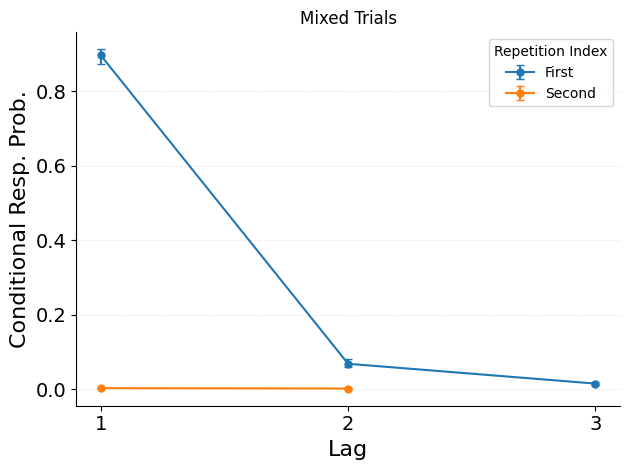

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


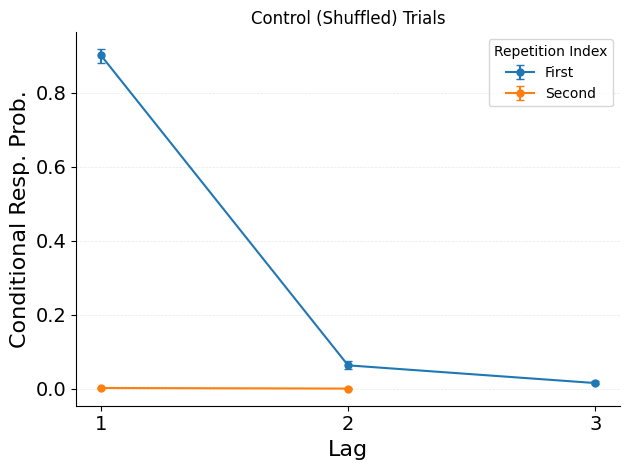

In [5]:
plot_rep_crp(
    datasets=data,
    trial_masks=mixed_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plt.title("Mixed Trials")
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

plot_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plt.title("Control (Shuffled) Trials")
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")


In [6]:
observed_crp = subject_serial_rep_crp(data, mixed_mask, min_lag, max_lag, size)
control_crp = subject_serial_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_serial_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print()
    print("=" * 60)
    print(f"Statistical Tests: {label}")
    print("=" * 60)
    print(result)



Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
    1 |   -2.274     0.0326 |     77.0     0.0366 |    -0.0053
    2 |    2.842     0.0092 |     58.0     0.0072 |     0.0042
    3 |   -2.148     0.0425 |     80.0     0.0457 |    -0.0013

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
    1 |   -0.573     0.5720 |     97.0     0.3382 |    -0.0002
    2 |    1.379     0.1812 |     35.0     0.2719 |     0.0004
    3 |      nan        nan |      nan        nan |        nan


/Users/jordangunn/jaxcmr/jaxcmr/analyses/serialrepcrp.py:515: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/serialrepcrp.py:526: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)
